In [1]:
# Note: Runs best in jupyter notebook.
# Please check repo to ensure all dependencies are installed

In [2]:
import cfgrib
import pandas as pd

In [ ]:
#Import our grib dataset

ds = cfgrib.open_dataset(r"C:\Users\path_to_your_file")

#ds = cfgrib.open_dataset(r'C:\path_to_your_grib_file.grib')

#Display our data set so we know which variables we'd like to work with

print(ds)

Ignoring index file 'C:\\Users\\nicc\\Desktop\\github_repo\\Leaf_disease_model\\climatedata.grib.5b7b6.idx' incompatible with GRIB file
skipping variable: paramId==228 shortName='tp'
Traceback (most recent call last):
  File "C:\Users\nicc\AppData\Local\Programs\Python\Python311\Lib\site-packages\cfgrib\dataset.py", line 725, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\nicc\AppData\Local\Programs\Python\Python311\Lib\site-packages\cfgrib\dataset.py", line 641, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1519862400, 1519884000, 1519905600, 1519927200, 1519948800,
       1519970400, 1519992000, 1520013600, 1520035200, 1520056800,
       1520078400, 1520100000, 1520121600, 1520143200, 1520164800,
       1520186400, 1520208000, 1520229600, 1520251200, 1520272800,
       1520294400, 1520316000, 1520337600, 1520359200, 152

<xarray.Dataset> Size: 138MB
Dimensions:     (time: 496, latitude: 100, longitude: 232)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 4kB 2018-03-01 ... 2024-10-31T18:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 800B 49.15 48.9 48.65 ... 24.9 24.65 24.4
  * longitude   (longitude) float64 2kB -124.8 -124.5 -124.3 ... -67.28 -67.03
    valid_time  (time) datetime64[ns] 4kB ...
Data variables:
    d2m         (time, latitude, longitude) float32 46MB ...
    t2m         (time, latitude, longitude) float32 46MB ...
    sp          (time, latitude, longitude) float32 46MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:      

C:\Users\nicc\AppData\Local\Programs\Python\Python311\Lib\site-packages\cfgrib\xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [5]:
lat_target = 36.123 #example lat cords in dataset
long_target = -122.456 #Example longe cords in dataset

point_data = ds.sel(latitude=lat_target, longitude=long_target, method='nearest') #Select data for specific lat/lon

print(point_data)

<xarray.Dataset> Size: 14kB
Dimensions:     (time: 496)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 4kB 2018-03-01 ... 2024-10-31T18:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    latitude    float64 8B 36.15
    longitude   float64 8B -122.5
    valid_time  (time) datetime64[ns] 4kB ...
Data variables:
    d2m         (time) float32 2kB ...
    t2m         (time) float32 2kB ...
    sp          (time) float32 2kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-24T10:32 GRIB to CDM+CF via cfgrib-0.9.1...


In [6]:
#Create our data frame from the selected point data
df = point_data.to_dataframe().reset_index()

print(df.head())

                 time  number   step  surface  latitude  longitude  \
0 2018-03-01 00:00:00       0 0 days      0.0     36.15    -122.53   
1 2018-03-01 06:00:00       0 0 days      0.0     36.15    -122.53   
2 2018-03-01 12:00:00       0 0 days      0.0     36.15    -122.53   
3 2018-03-01 18:00:00       0 0 days      0.0     36.15    -122.53   
4 2018-03-02 00:00:00       0 0 days      0.0     36.15    -122.53   

           valid_time         d2m         t2m           sp  
0 2018-03-01 00:00:00  281.267456  285.046143  102127.7500  
1 2018-03-01 06:00:00  282.773376  285.300537  102030.1875  
2 2018-03-01 12:00:00  283.349487  285.366302  101617.1875  
3 2018-03-01 18:00:00  283.755371  286.083984  101475.1250  
4 2018-03-02 00:00:00  284.352356  285.959473  101237.6250  


In [7]:
# Time series preprosseing freature

df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

#On an hourly series, this calculates a 7-point mean, not a 7-day one. If you want a true 7-day statistic, 
#consider a time-based window like `rolling('7D')` on the DatetimeIndex, especially if the sampling frequency might change.
df['t2m_7d_avg'] = df['t2m'].rolling(window=7).mean()

df.dropna(inplace=True)  #Lastly we drop missing values after rolling window

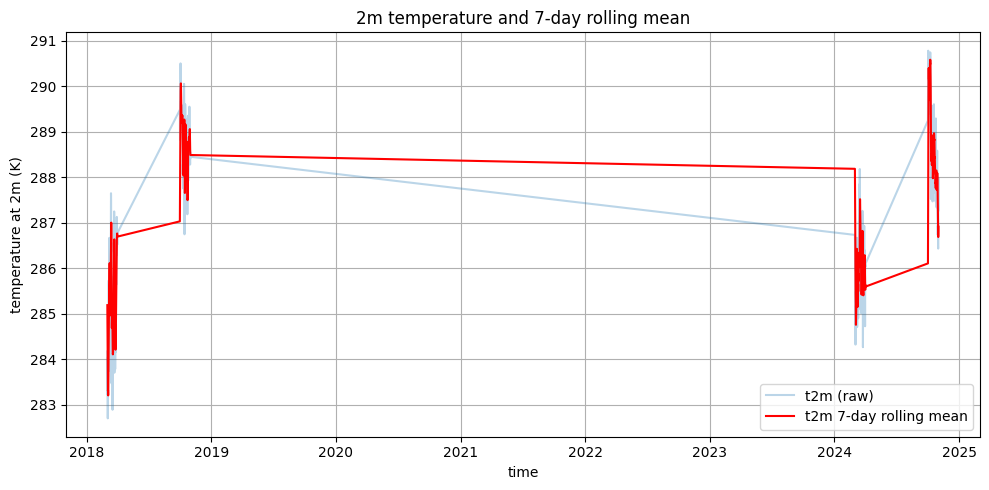

Summary of Statistics (K):
              t2m  t2m_7d_avg
count  490.000000  490.000000
mean   287.157410  287.146438
std      1.837816    1.756919
min    282.703125  283.207066
25%    285.653549  285.639648
50%    287.216156  287.259175
75%    288.708130  288.626953
max    290.776611  290.578474


In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df["t2m"], label="t2m (raw)", alpha=0.3)
plt.plot(df.index, df["t2m_7d_avg"], label="t2m 7‑day rolling mean", color="red")
plt.xlabel("time")
plt.ylabel("temperature at 2m (K)")
plt.title("2m temperature and 7‑day rolling mean")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Summary of Statistics
print("Summary of Statistics (K):")
print(df[["t2m", "t2m_7d_avg"]].describe())

In [9]:
#monthly aggregation

monthly_t2m = df["t2m"].resample("M").mean()
monthly_t2m_7d = df["t2m_7d_avg"].resample("M").mean()

summary = pd.DataFrame({
"t2m_monthly_mean": monthly_t2m,
"t2m_7d_monthly_mean": monthly_t2m_7d,
})

summary = summary.dropna(how="all")
print(summary.head())

            t2m_monthly_mean  t2m_7d_monthly_mean
time                                             
2018-03-31        285.209290           285.176261
2018-10-31        288.737152           288.693872
2024-03-31        285.944550           286.007645
2024-10-31        288.644257           288.612644


C:\Users\nicc\AppData\Local\Temp\ipykernel_13332\3491210189.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_t2m = df["t2m"].resample("M").mean()
C:\Users\nicc\AppData\Local\Temp\ipykernel_13332\3491210189.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_t2m_7d = df["t2m_7d_avg"].resample("M").mean()


In [ ]:
import os

# Specify output directory
out_dir = r"C:\Users\path_to_desired_output"

# Create directory if it doesn't exist
os.makedirs(out_dir, exist_ok=True)

# Export full time‑series (with time as a column)
df.reset_index().to_csv(os.path.join(out_dir, "climate_timeseries_with_7d_avg.csv"), index=False)

# Export monthly summary
summary.reset_index().to_csv(os.path.join(out_dir, "climate_monthly_summary.csv"), index=False)


In [ ]:
import os

OUT_DIR = r"C:\Users\Label_out_dir"
os.makedirs(OUT_DIR, exist_ok=True)

df.reset_index().to_csv(
    os.path.join(OUT_DIR, "climate_timeseries_with_7d_avg.csv"),
    index=False,
)